<a href="https://colab.research.google.com/github/nicolasvargaszz/Datamining_Forecasting/blob/main/DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# This notebook contains the data analysis that will help me to select the best forecast data, this will help the project to be closer to the reality of the company.

1


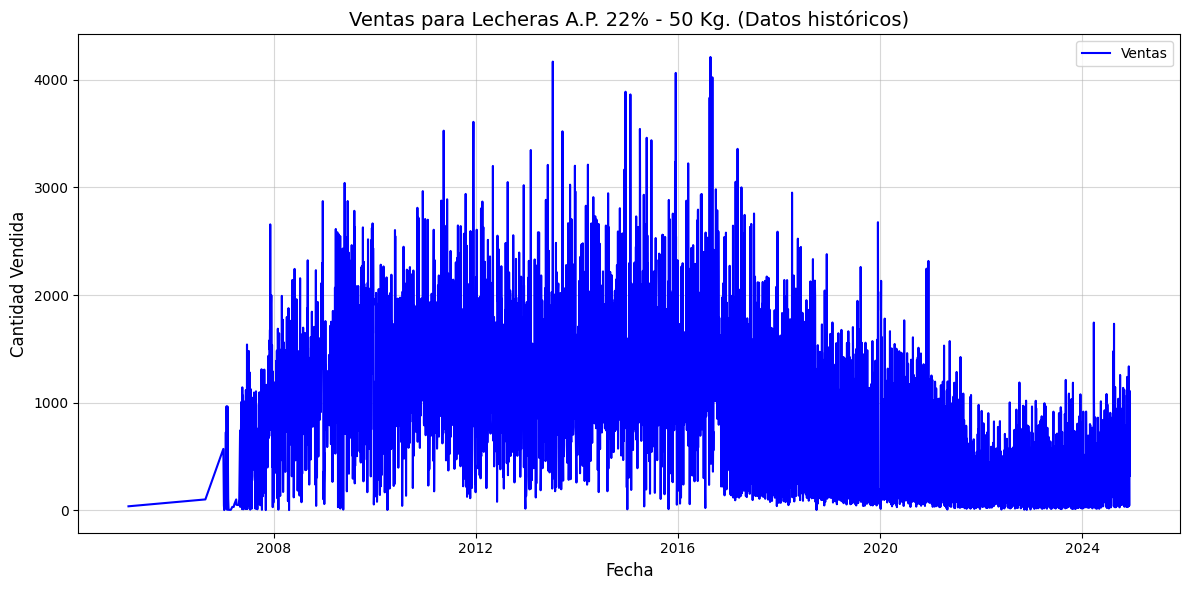

2


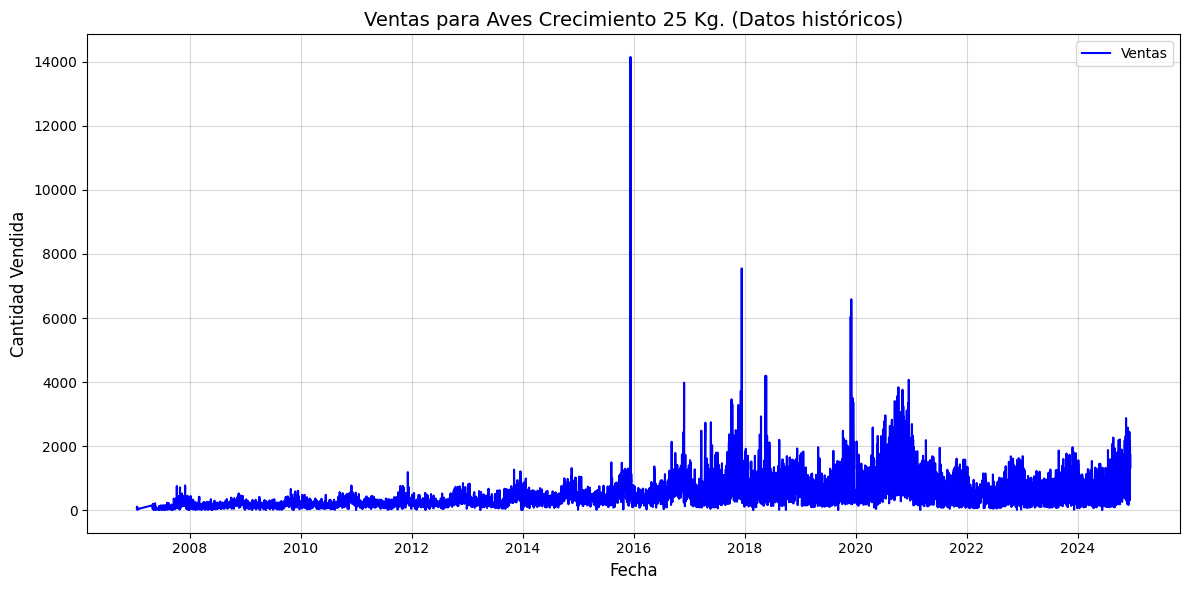

3


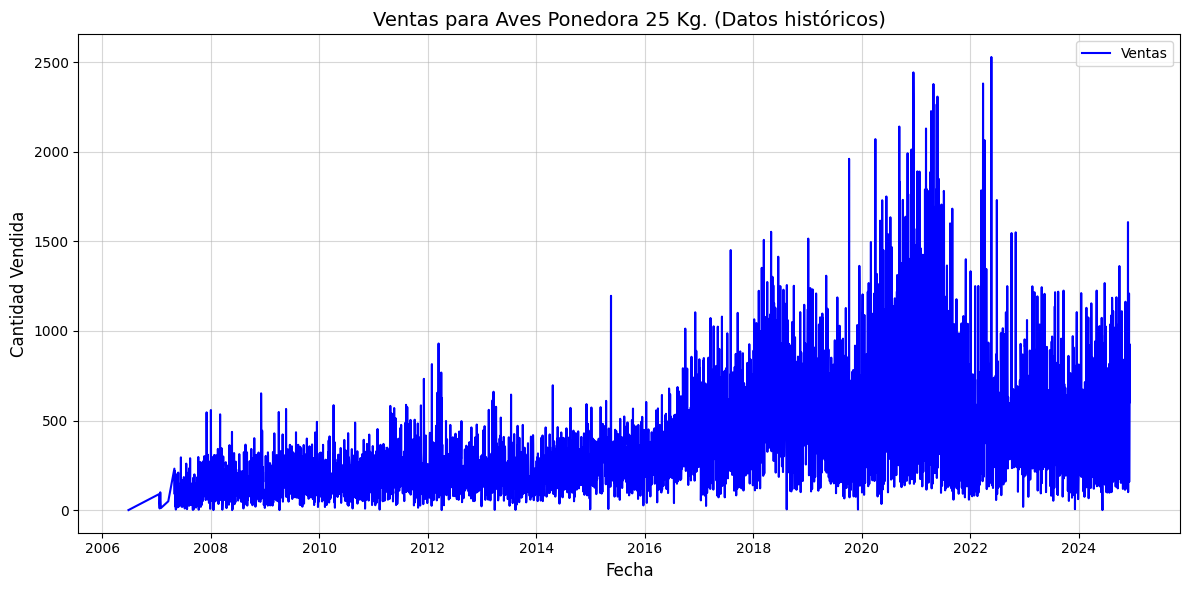

4


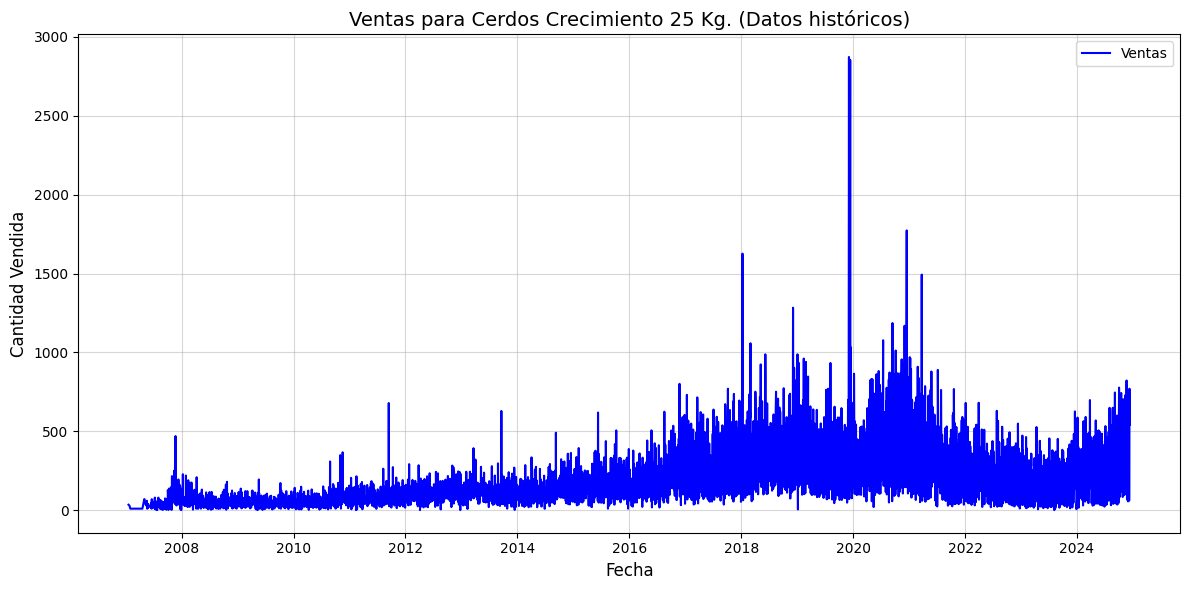

5


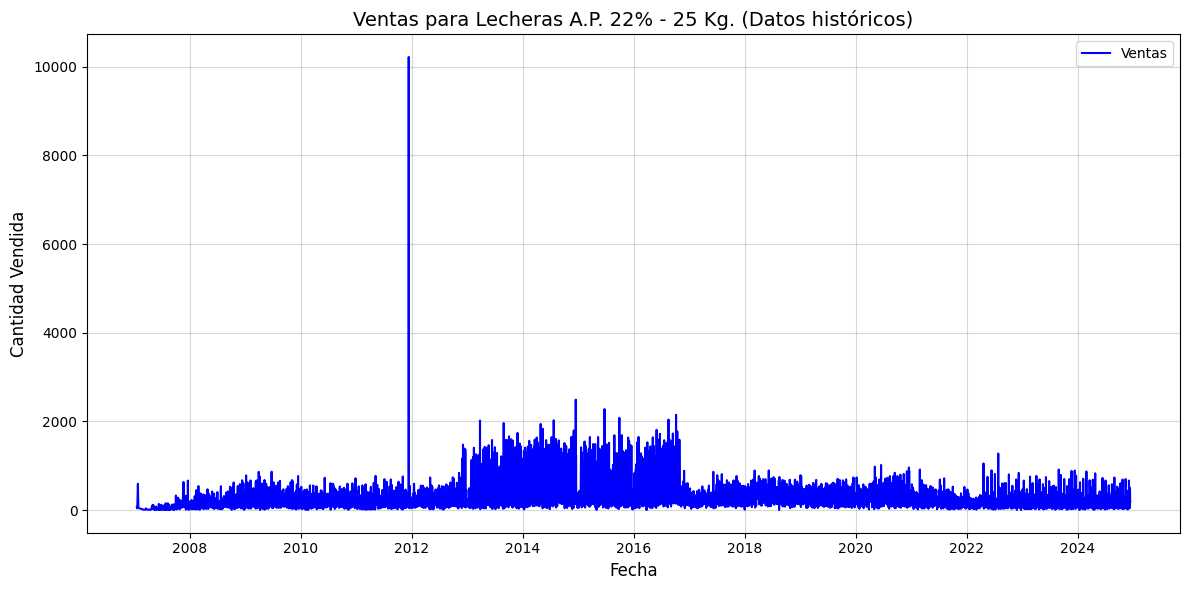

6


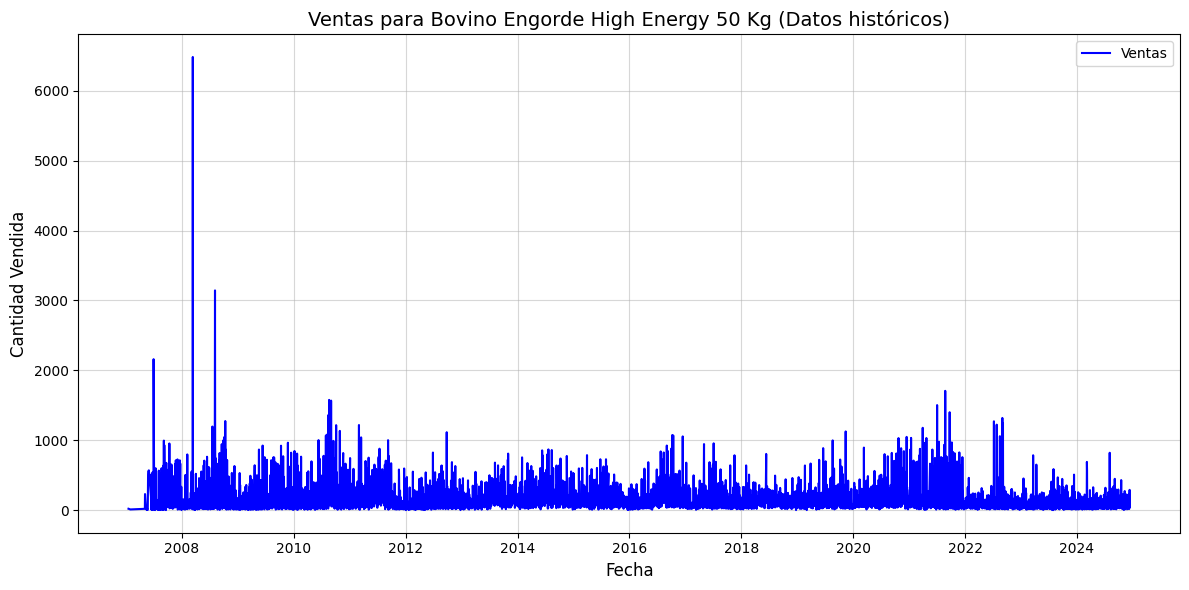

7


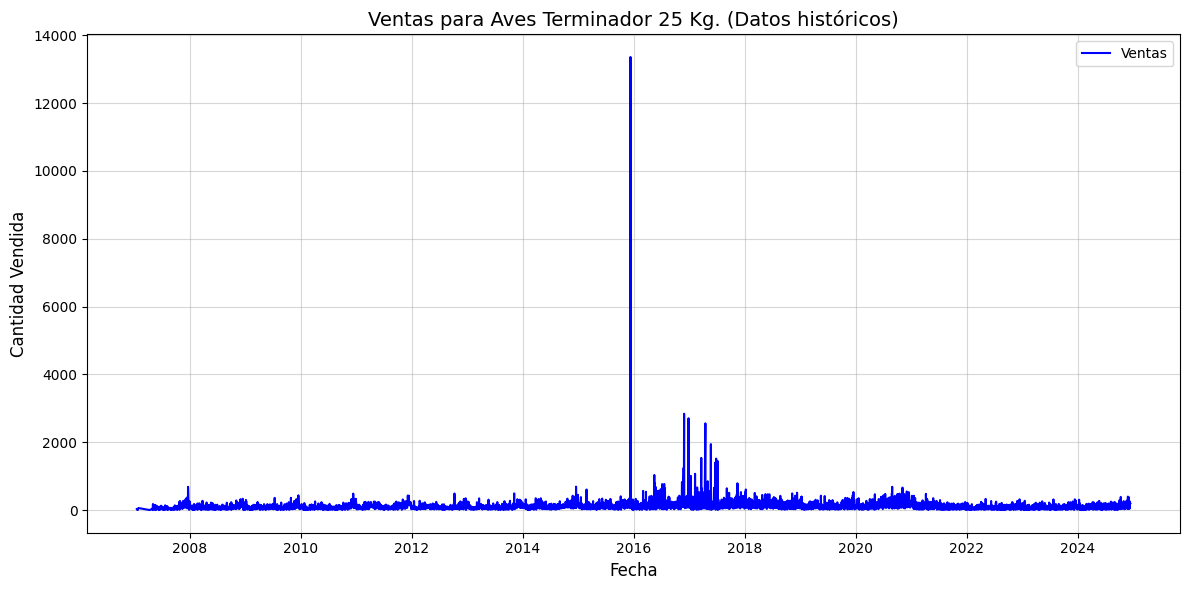

8


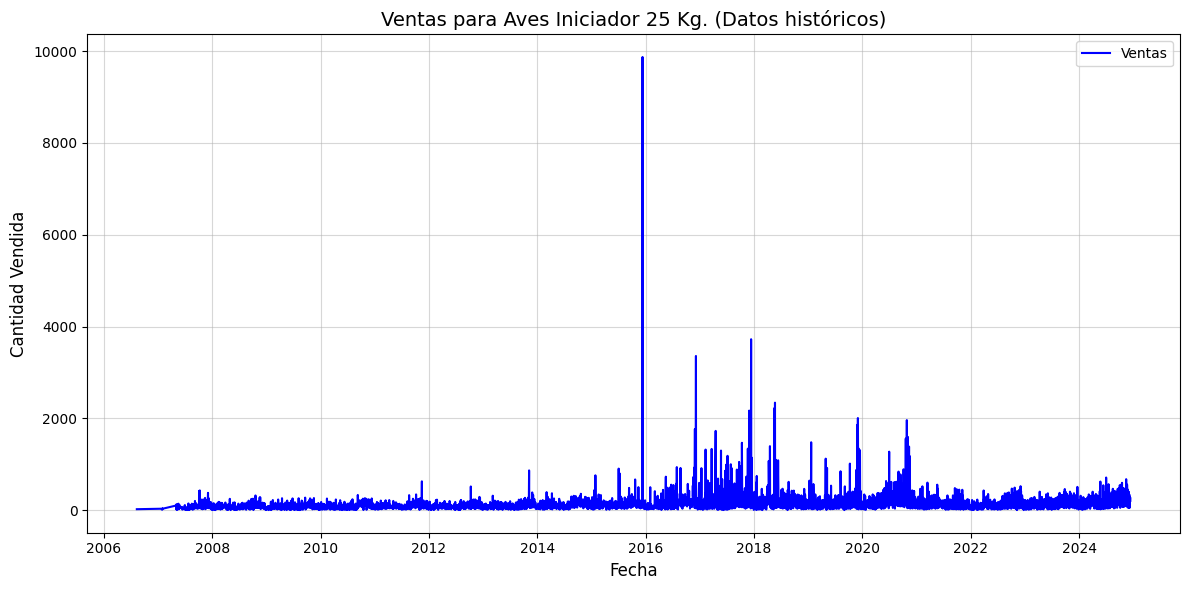

9


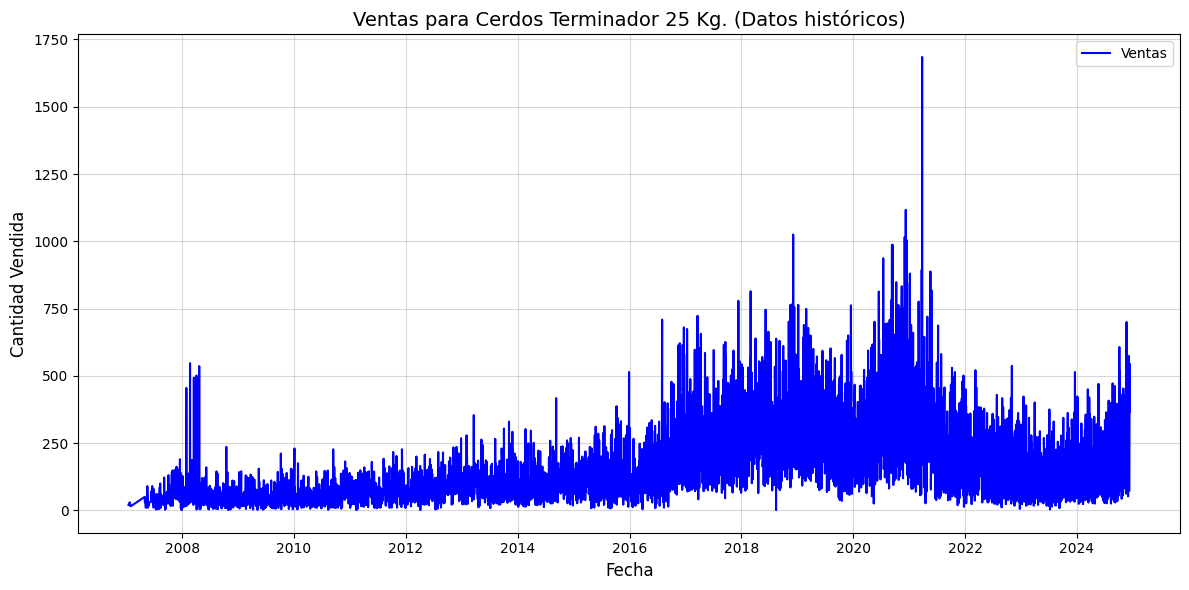

10


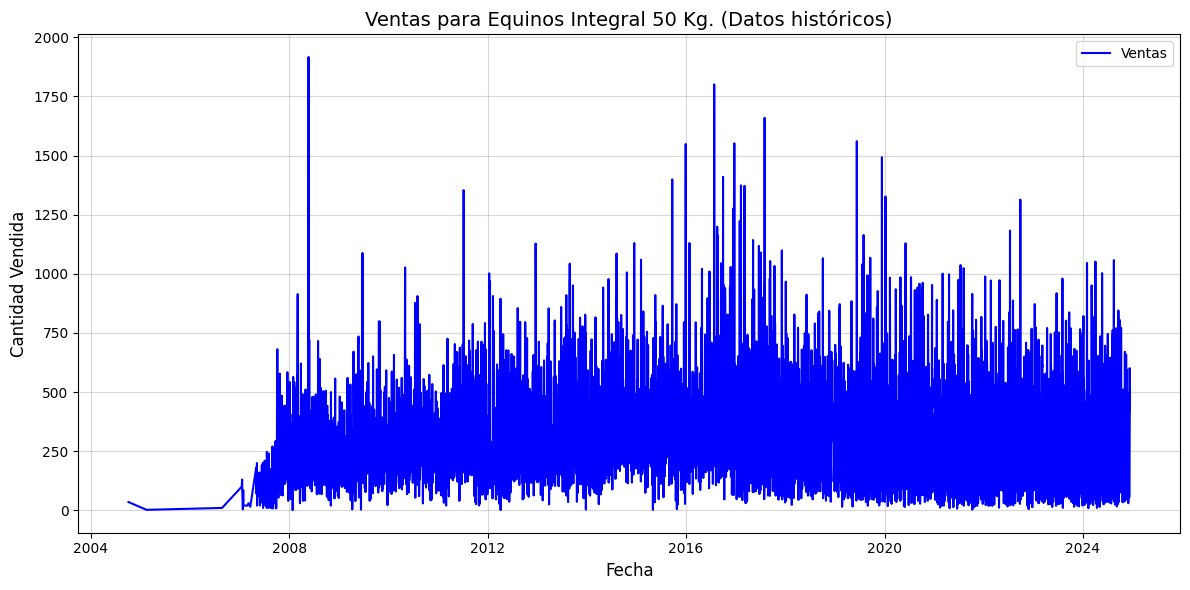

11


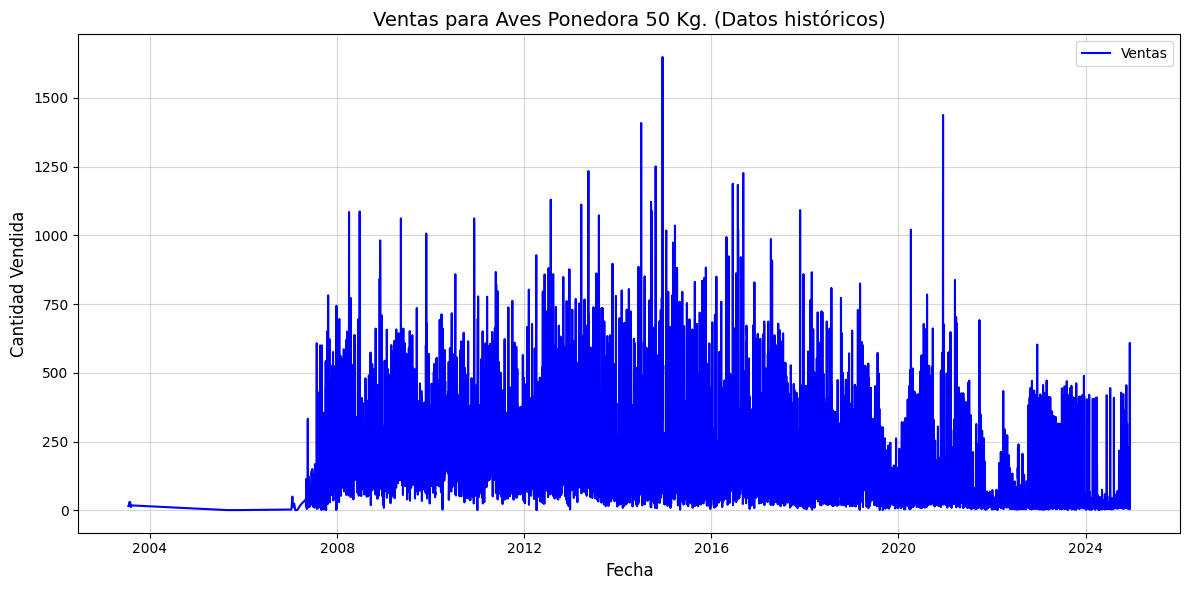

12


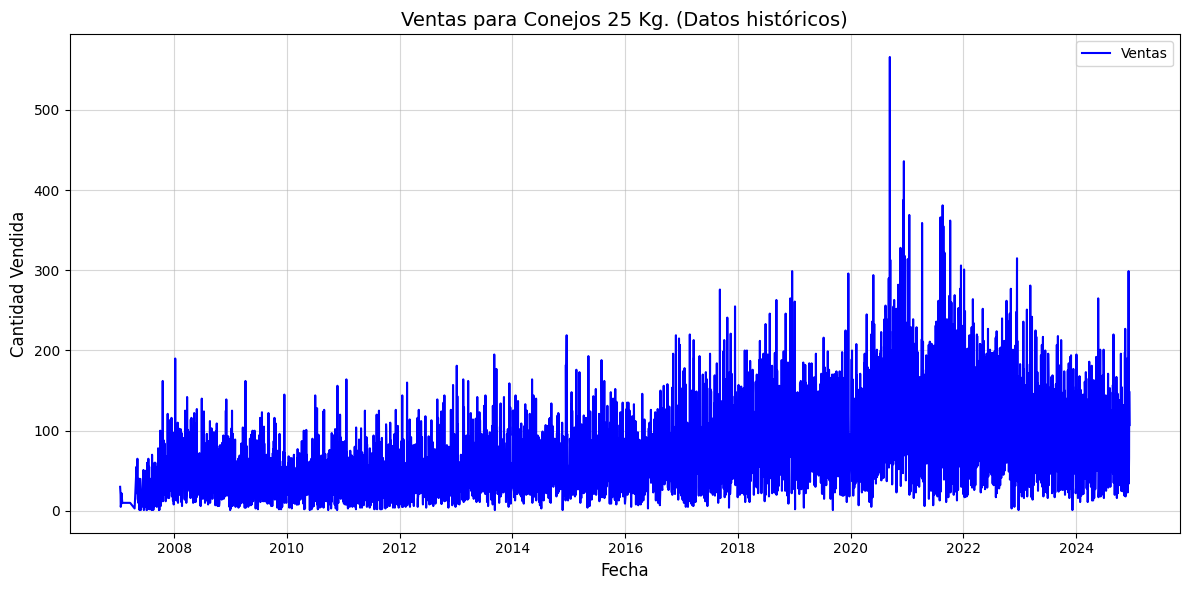

13


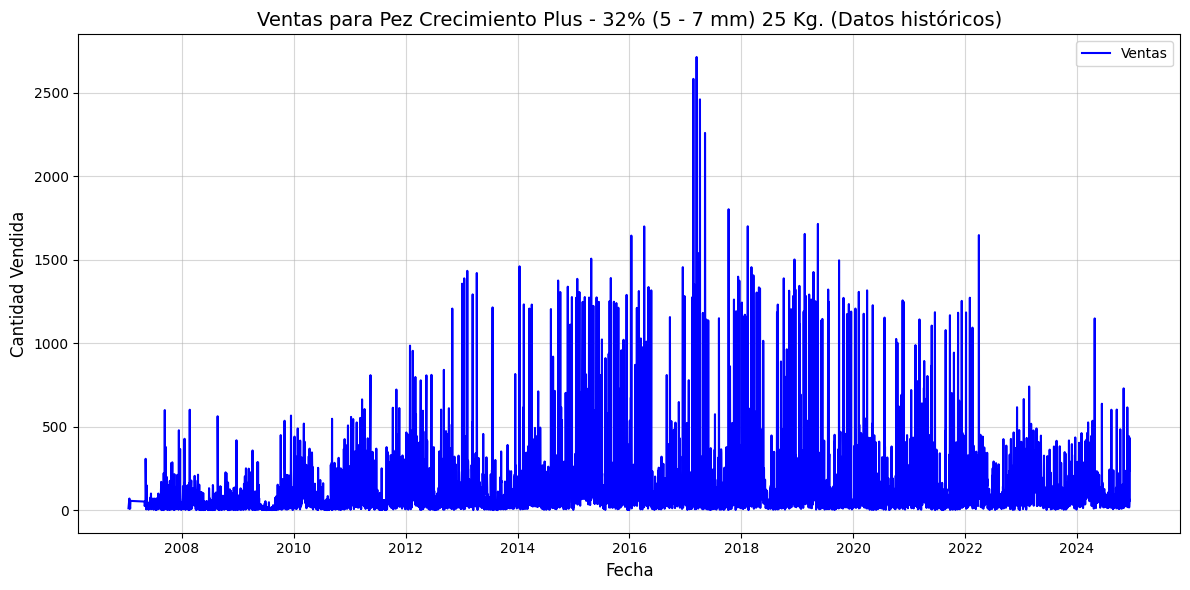

14


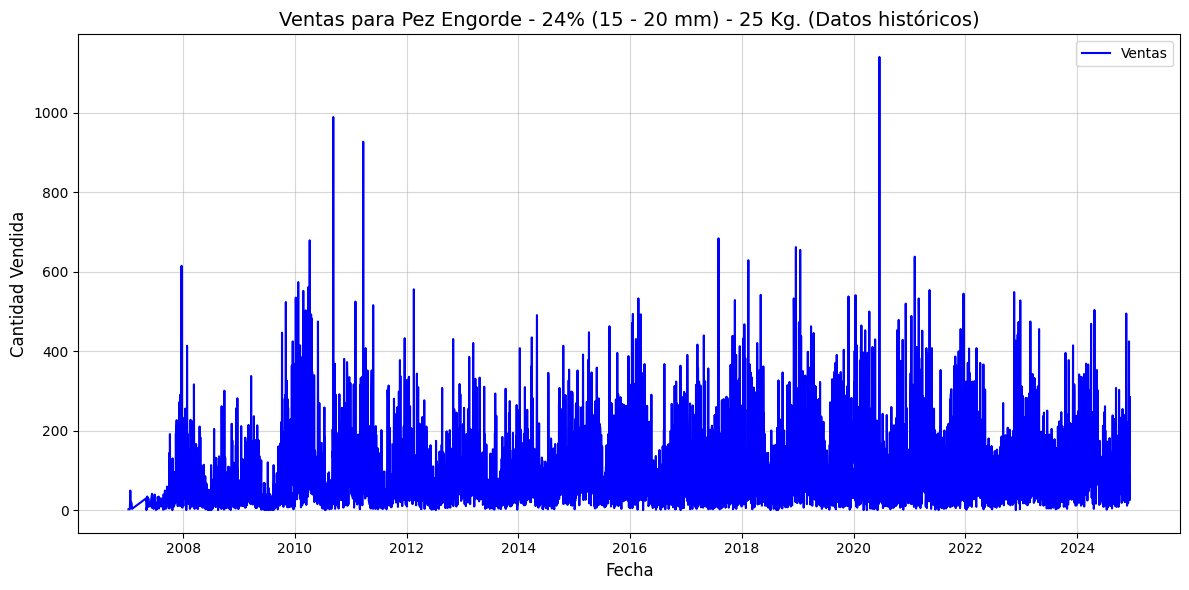

15


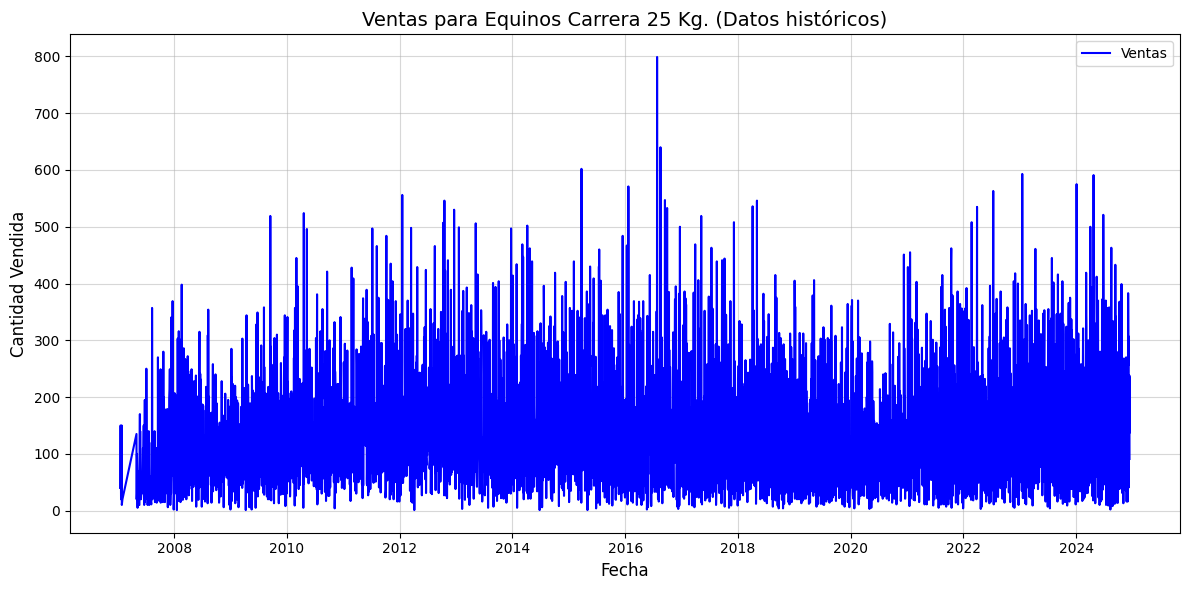

16


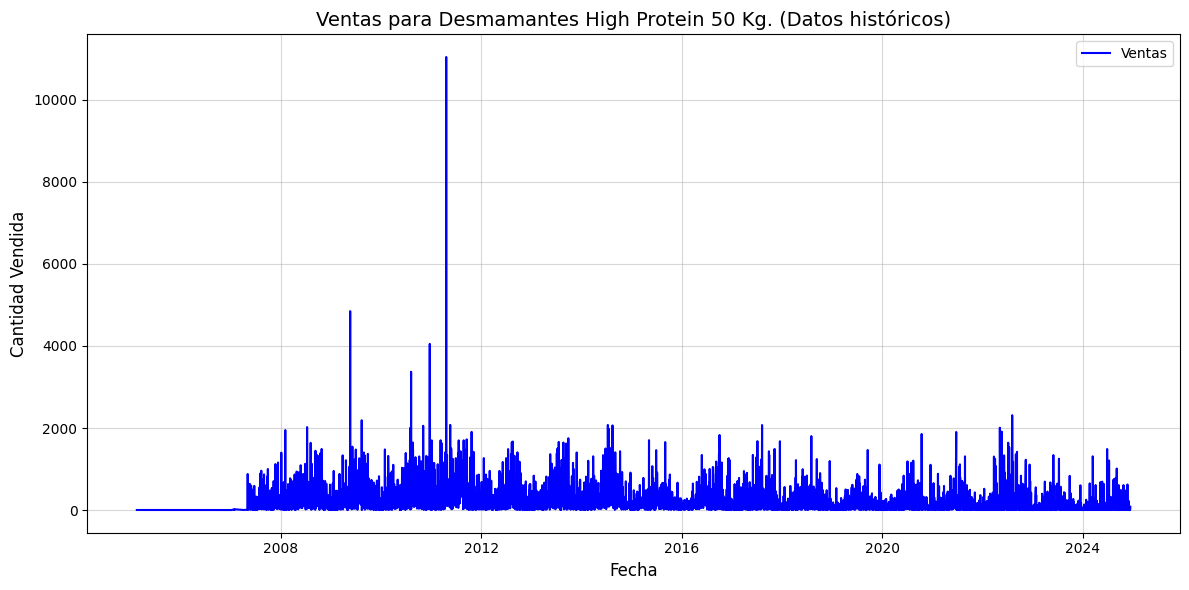

17


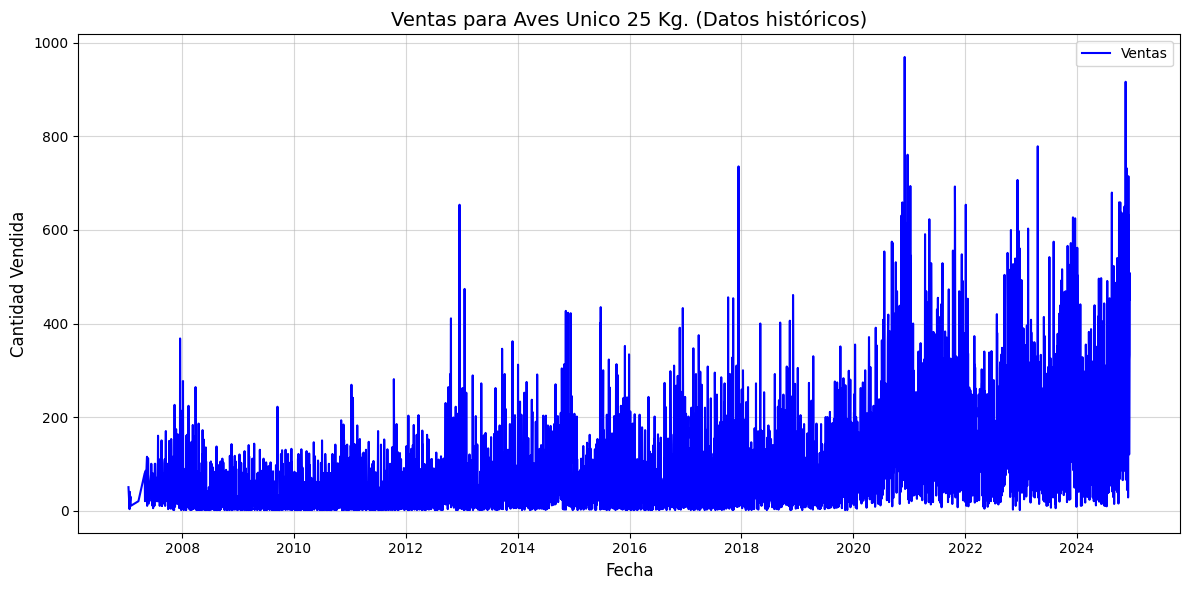

18


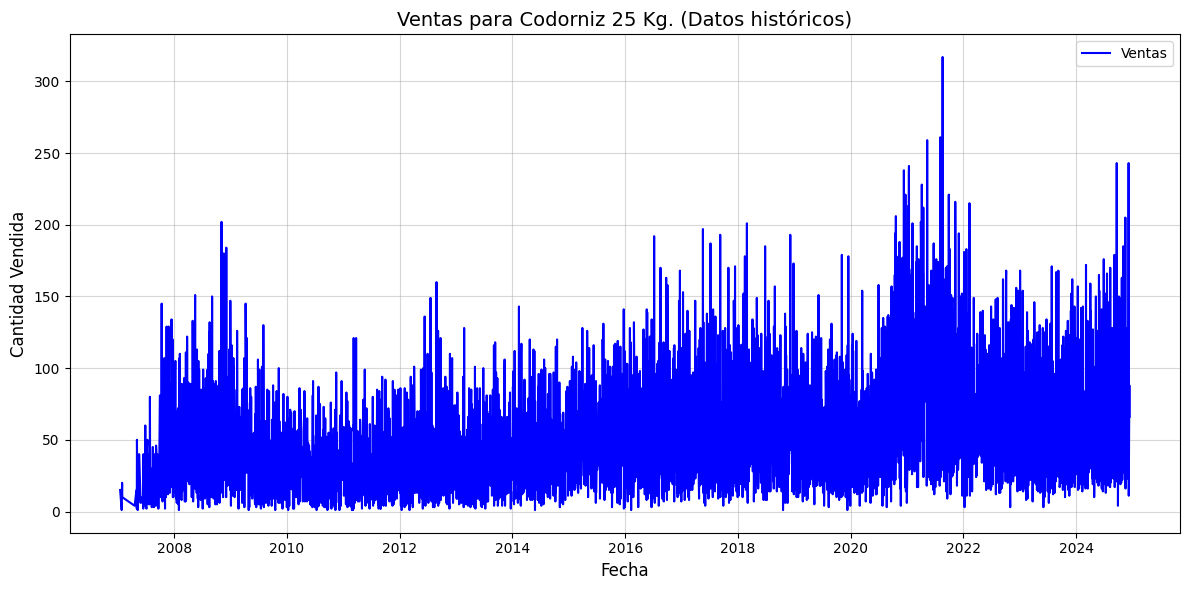

19


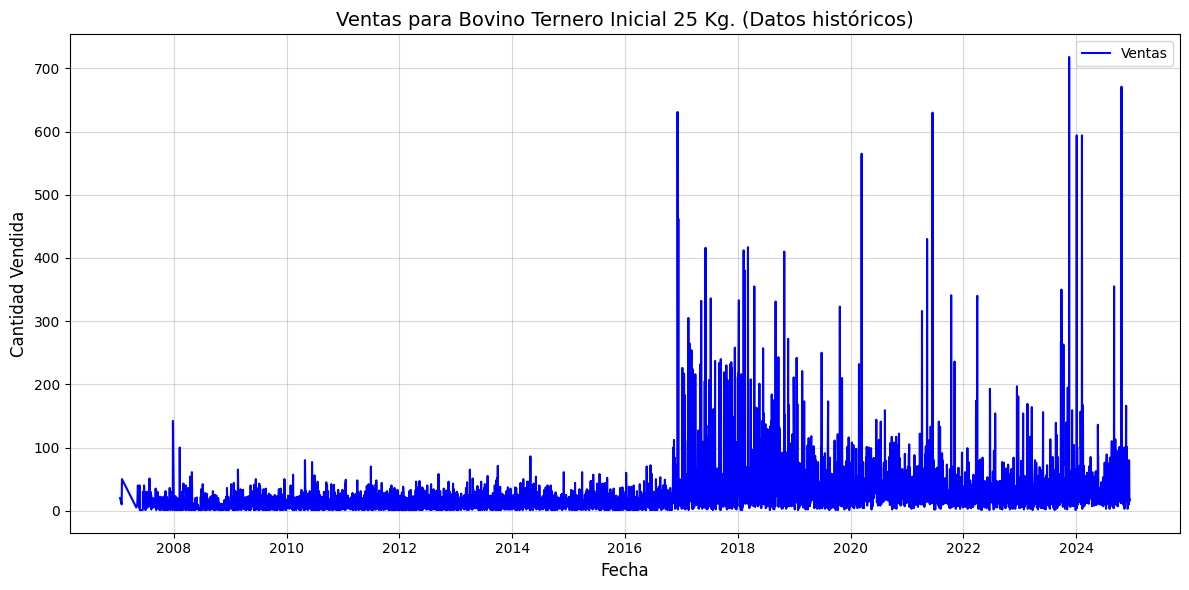

20


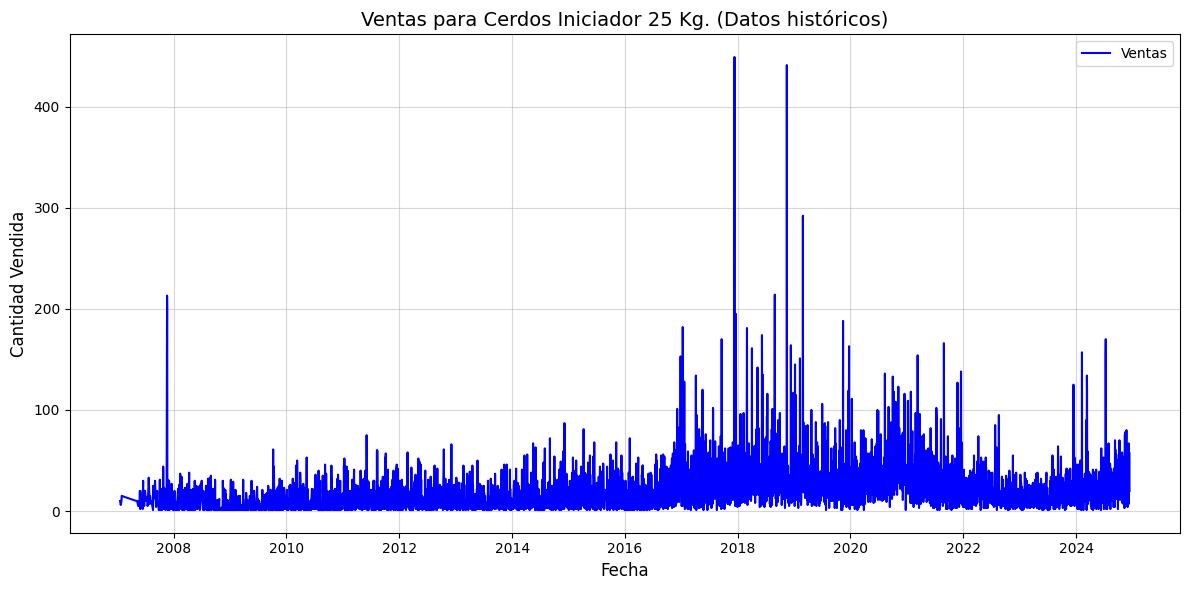

21


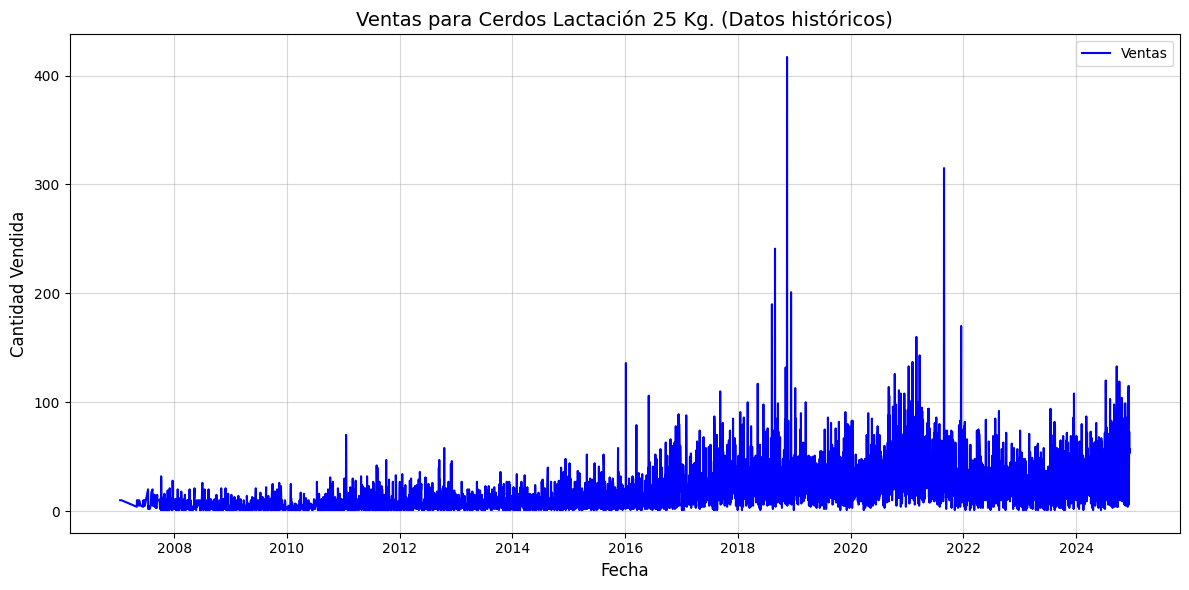

22


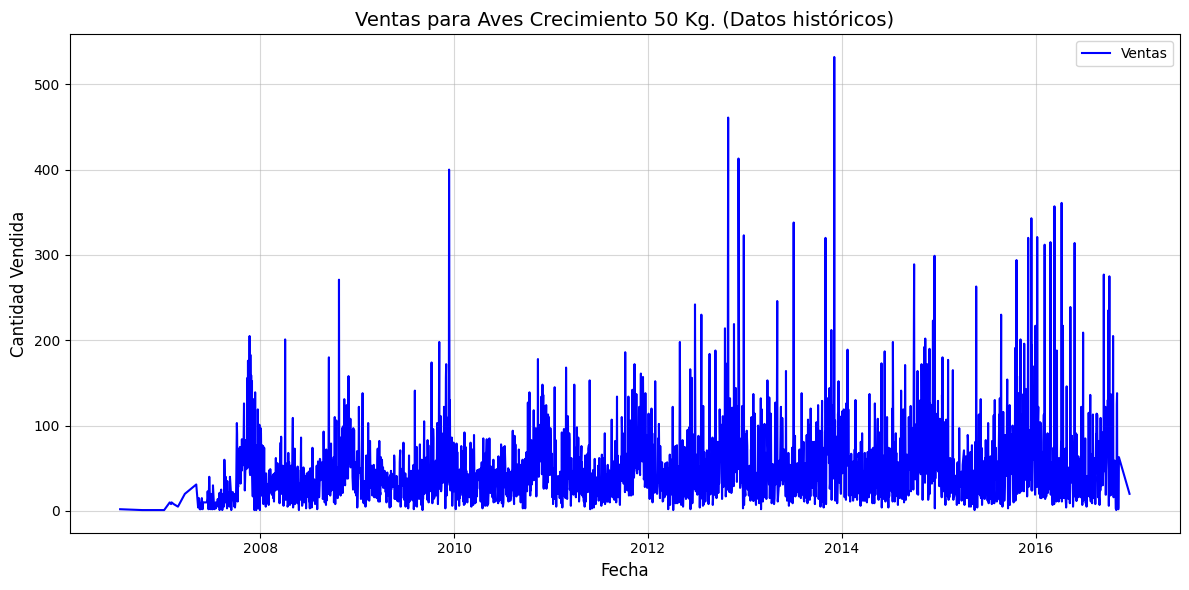

23


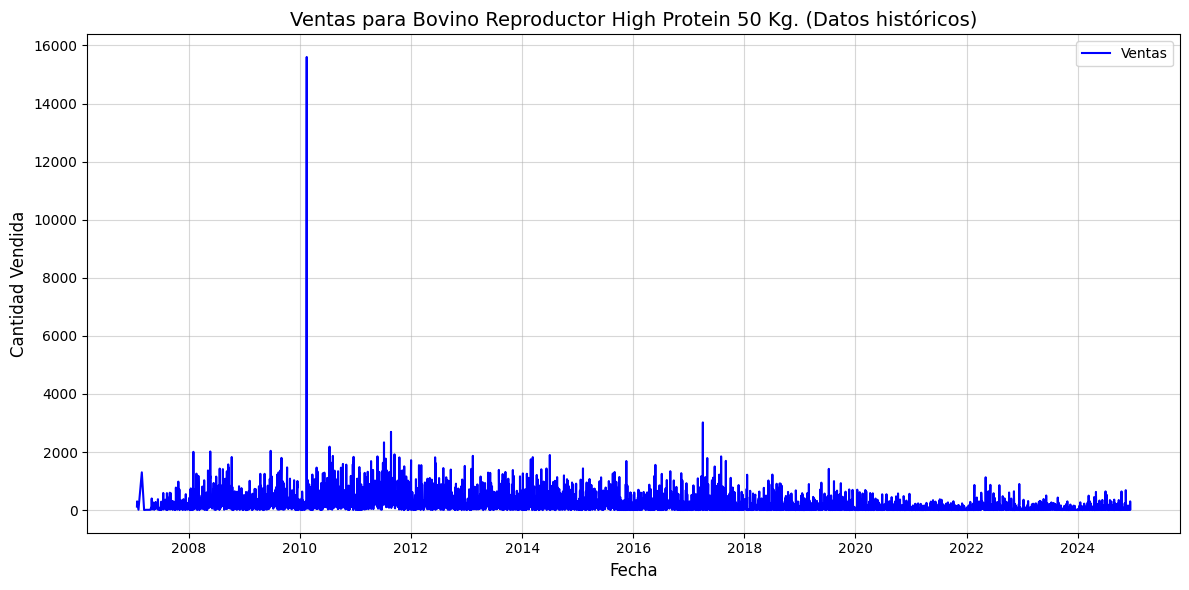

24


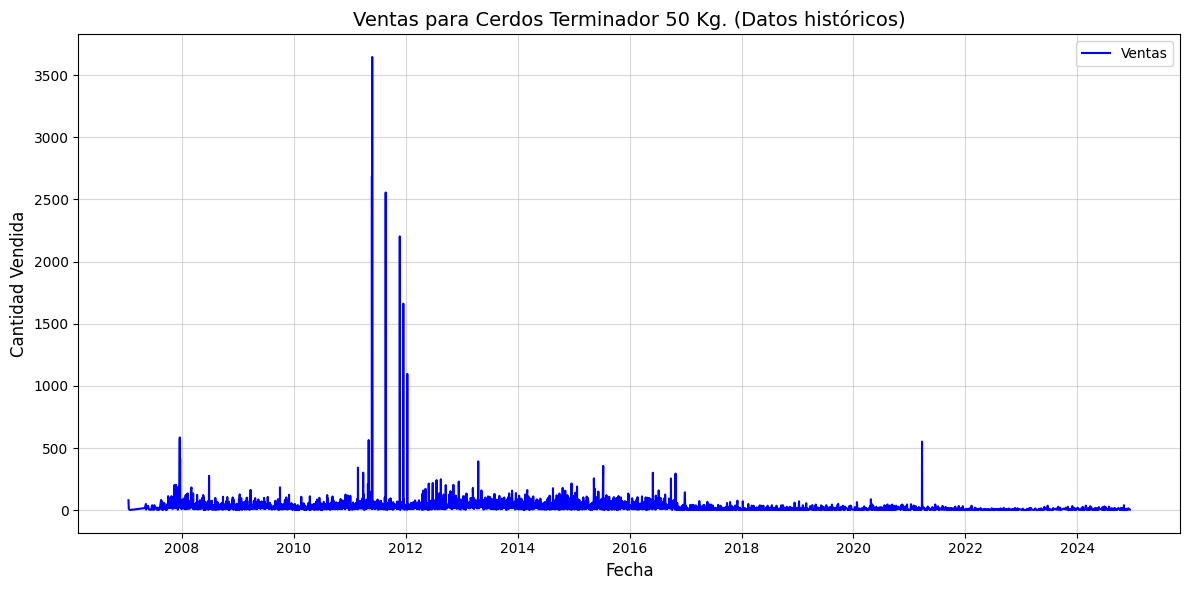

25


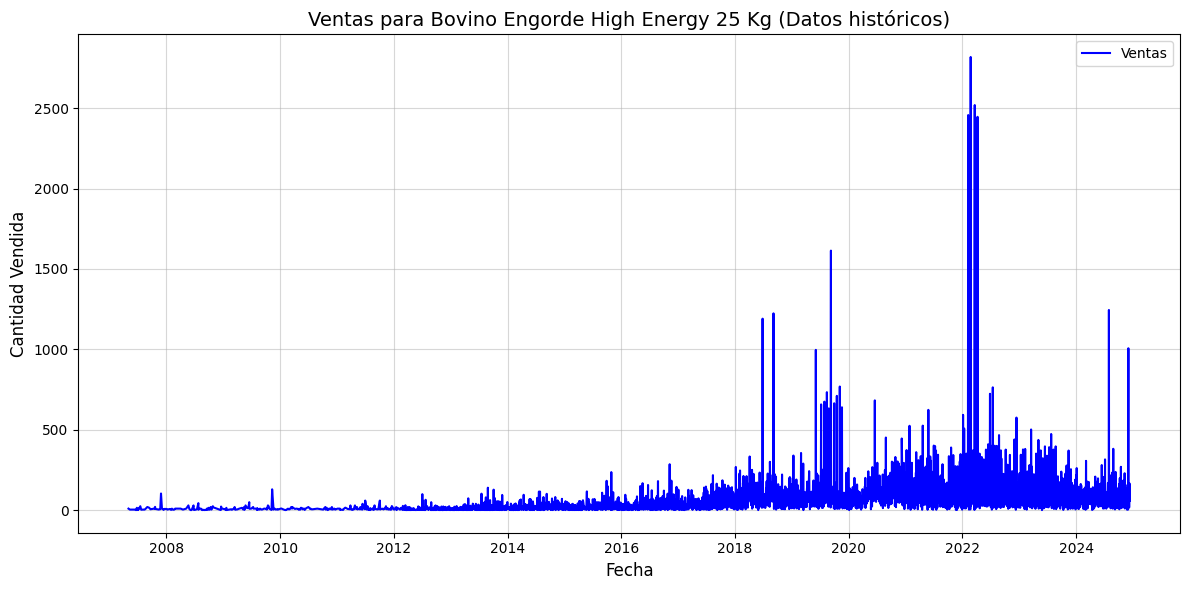

26


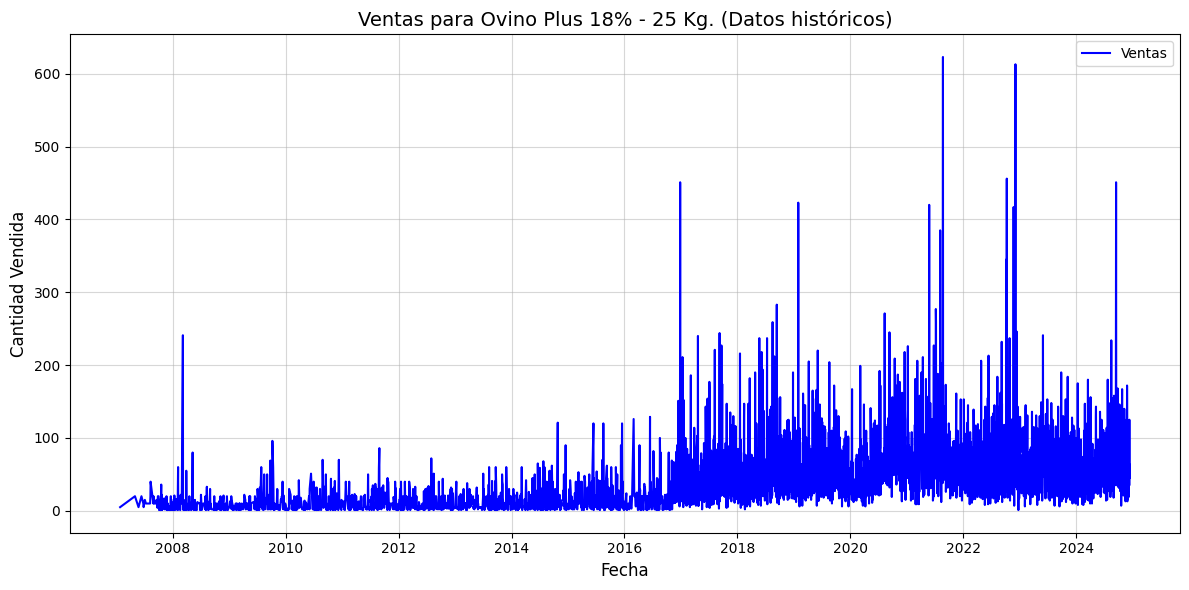

27


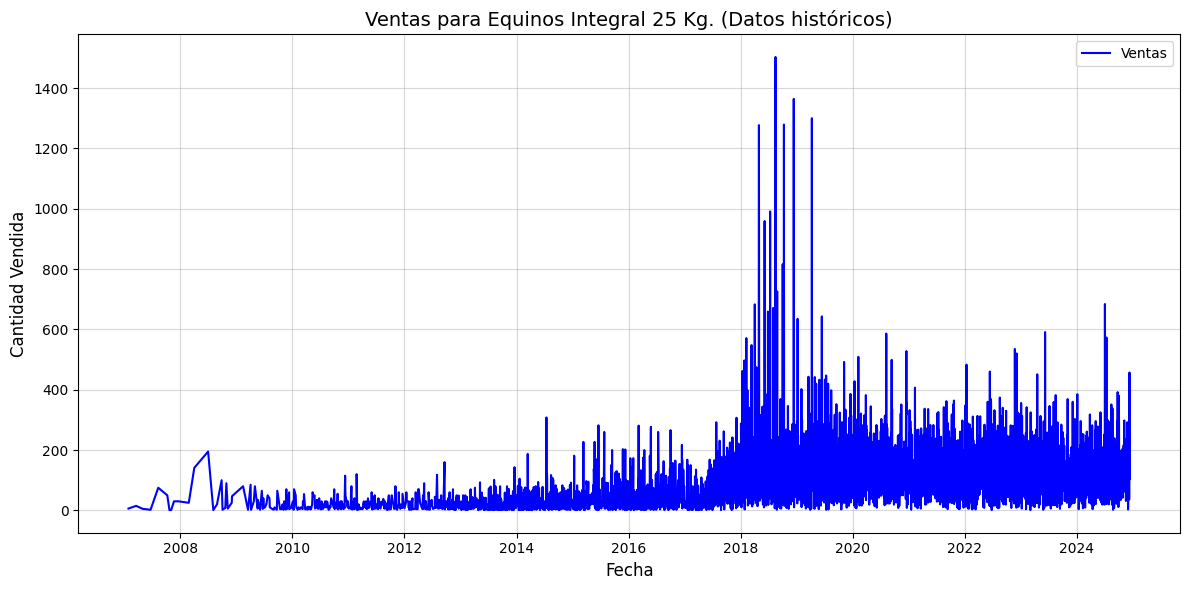

28


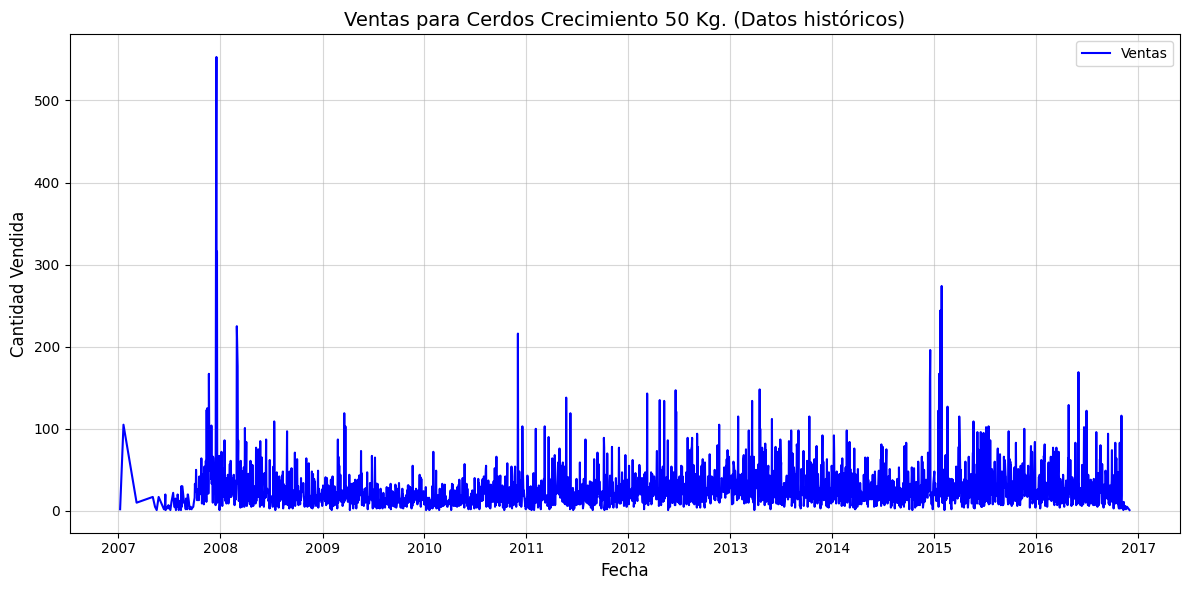

29


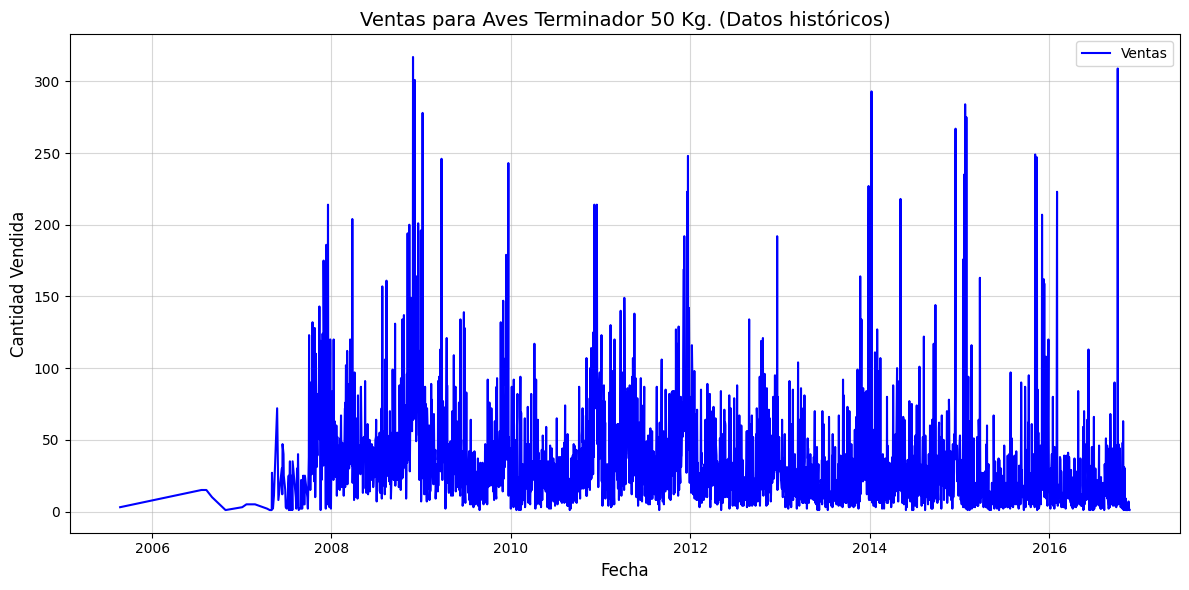

30


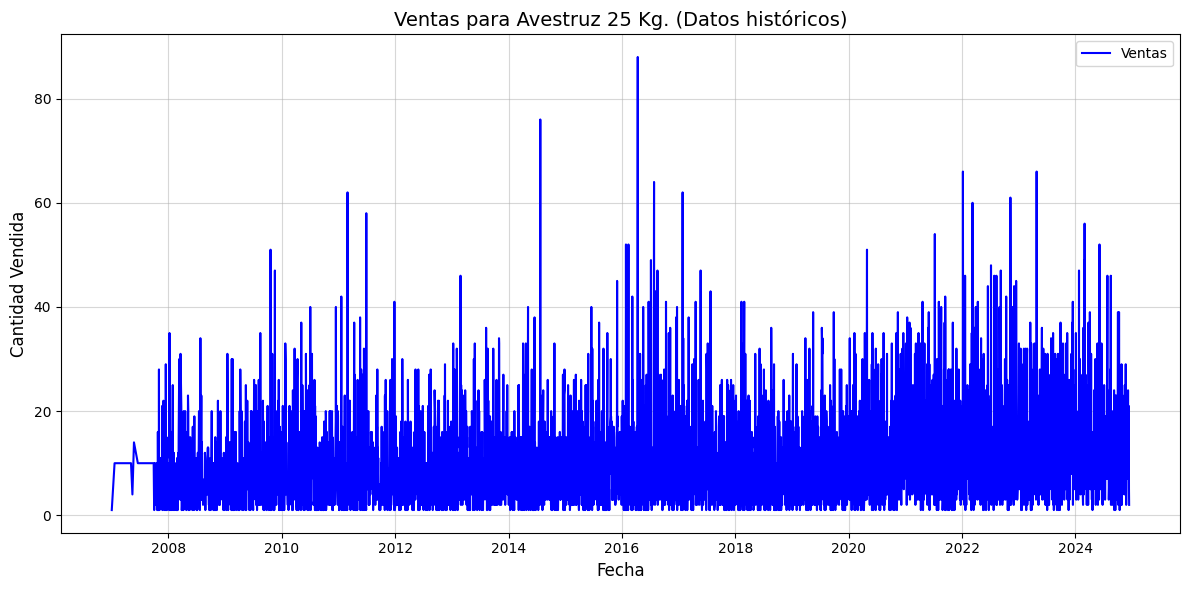

31


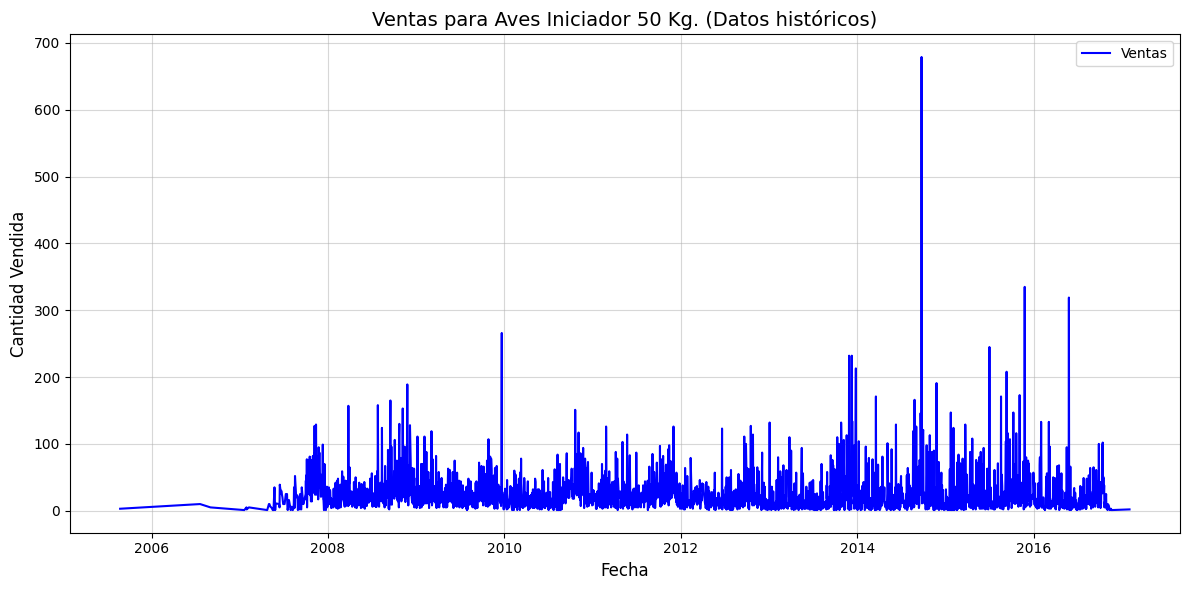

32


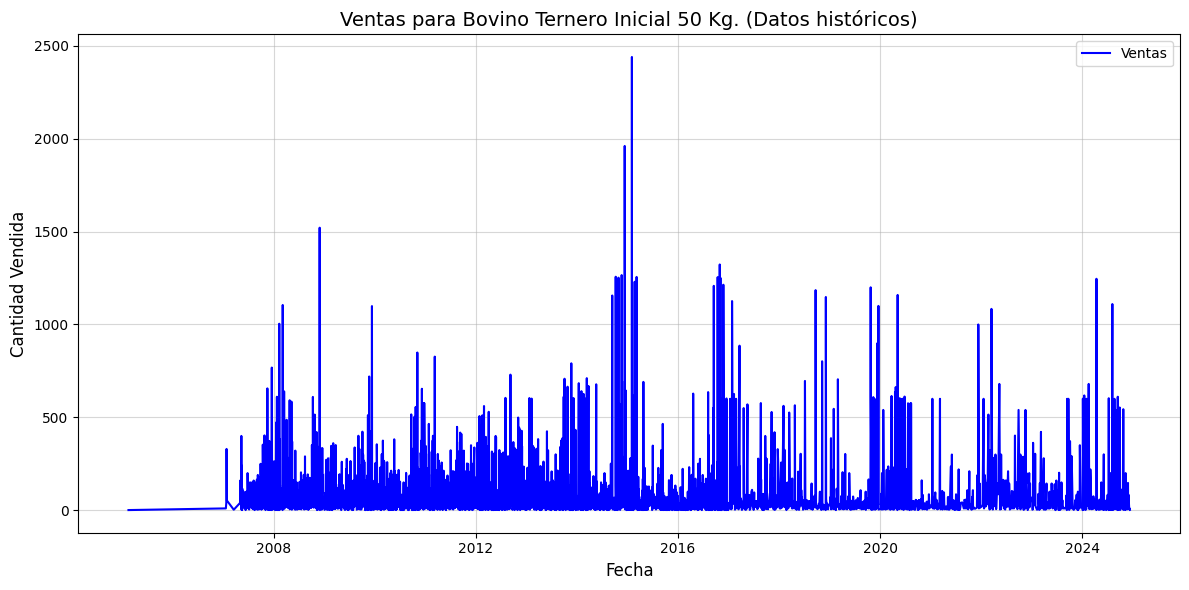

33


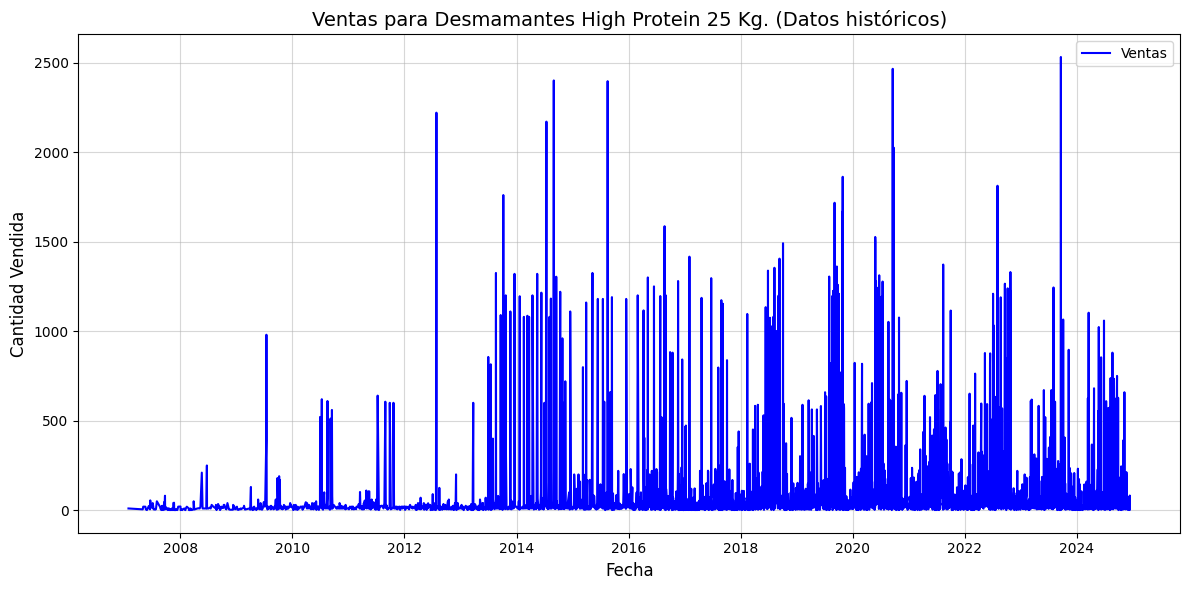

34


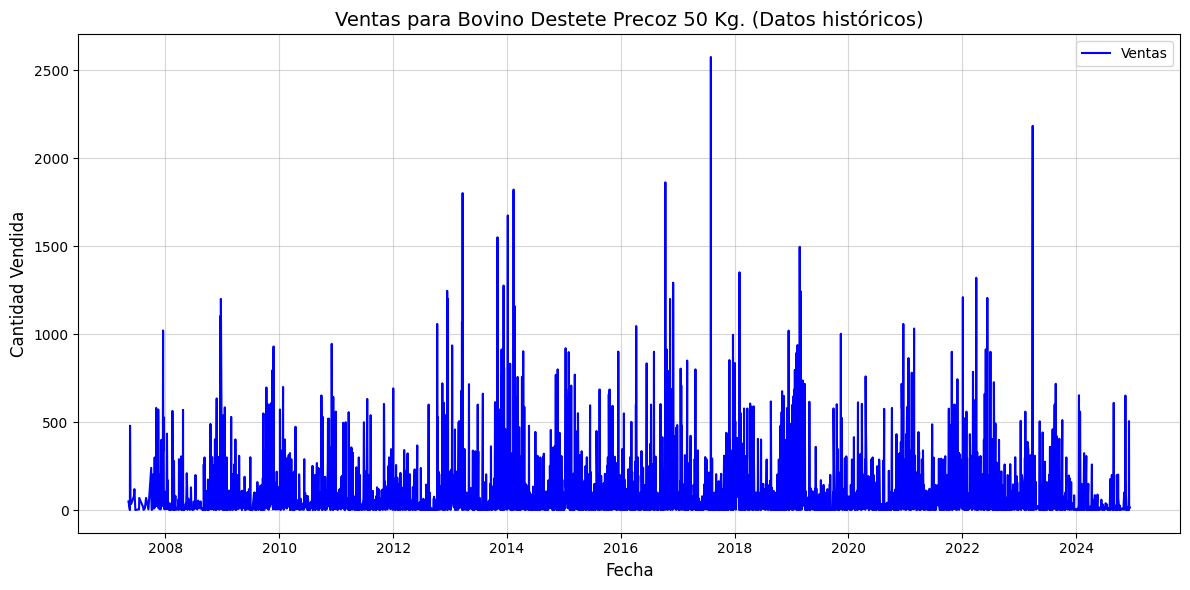

35


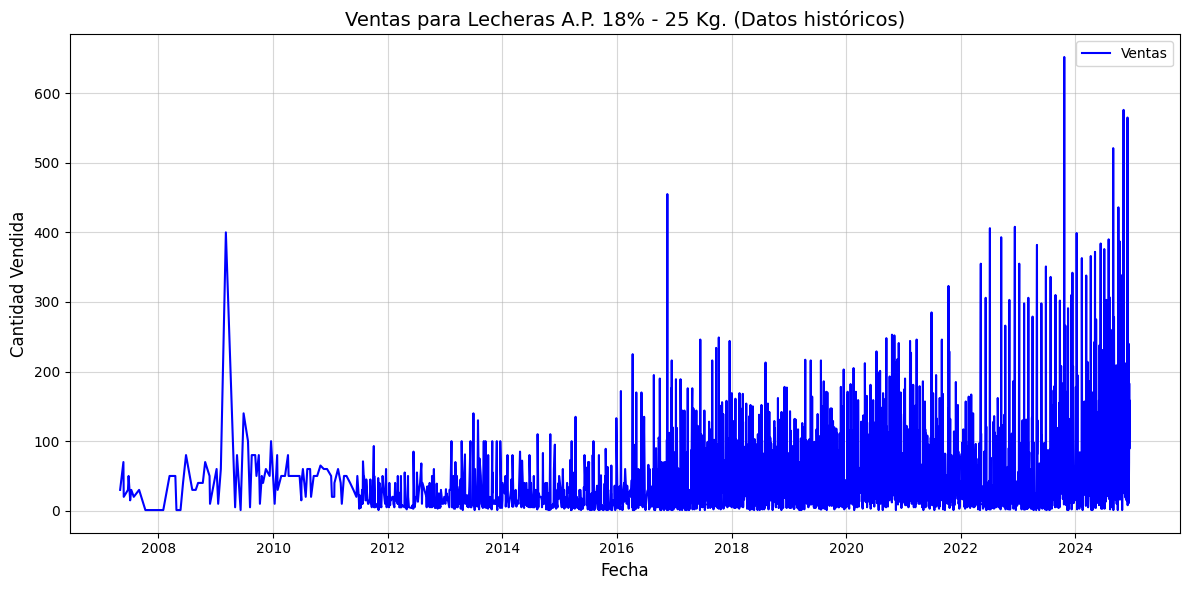

36


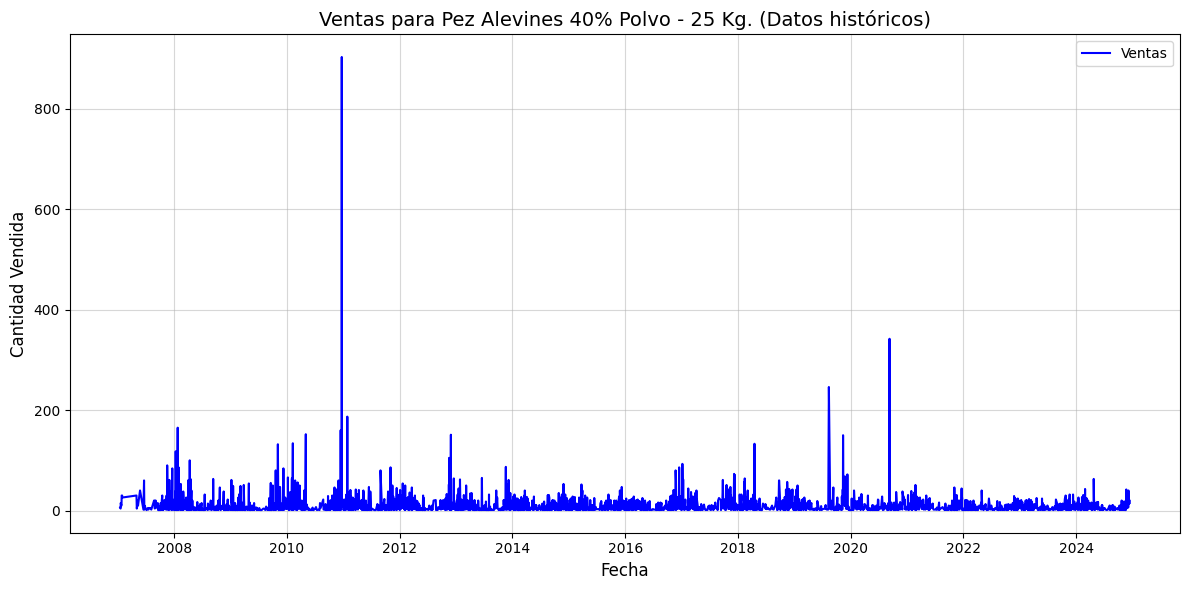

37


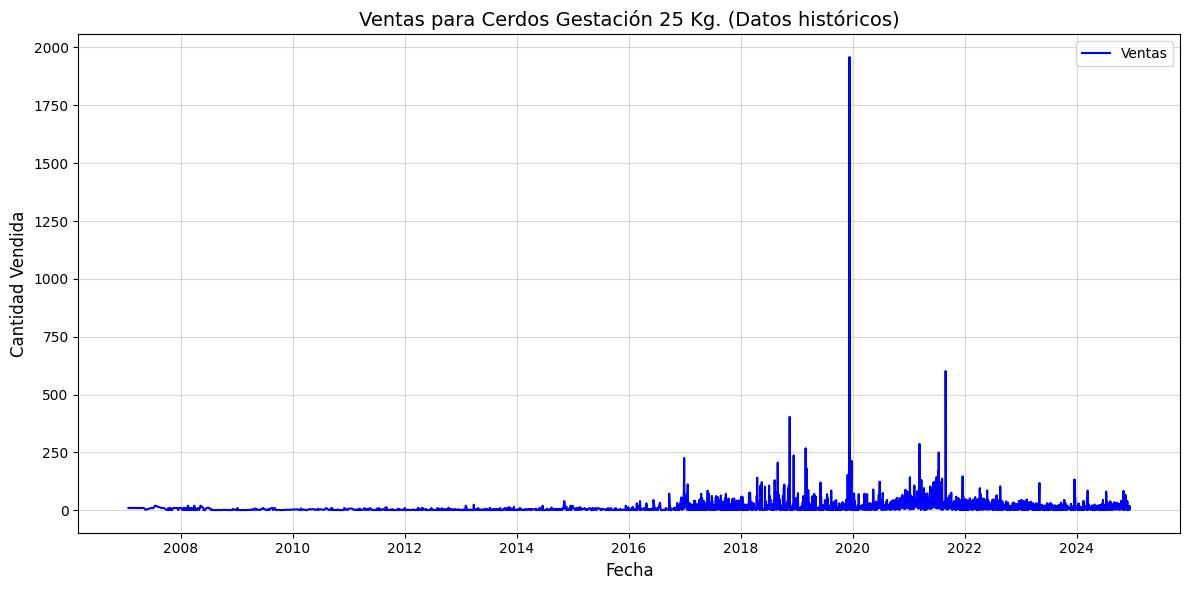

38


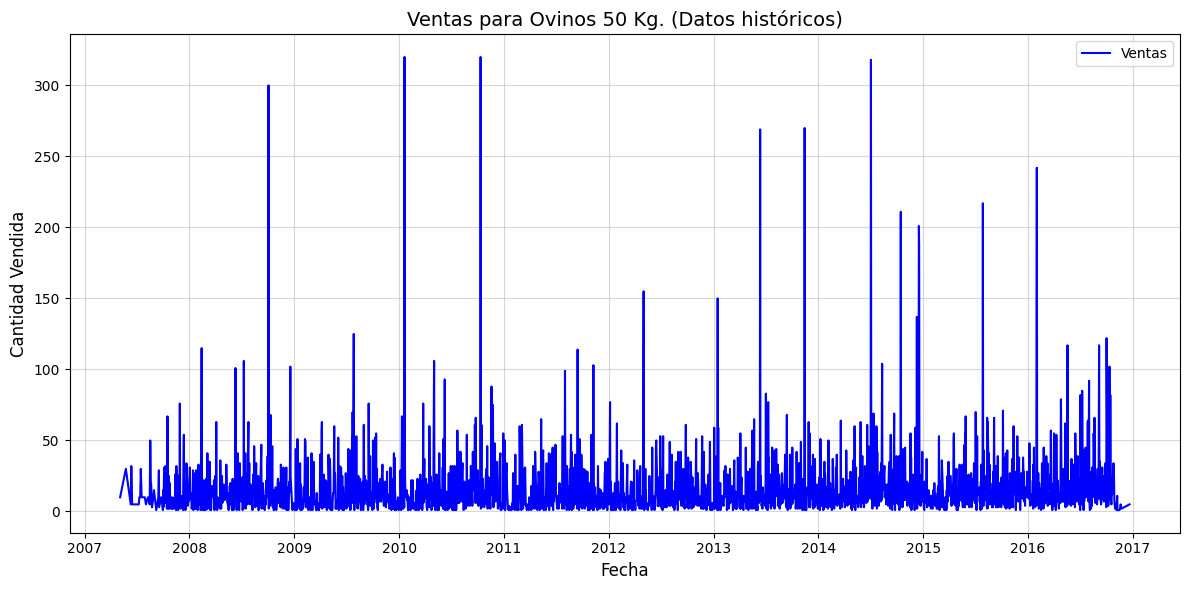

39


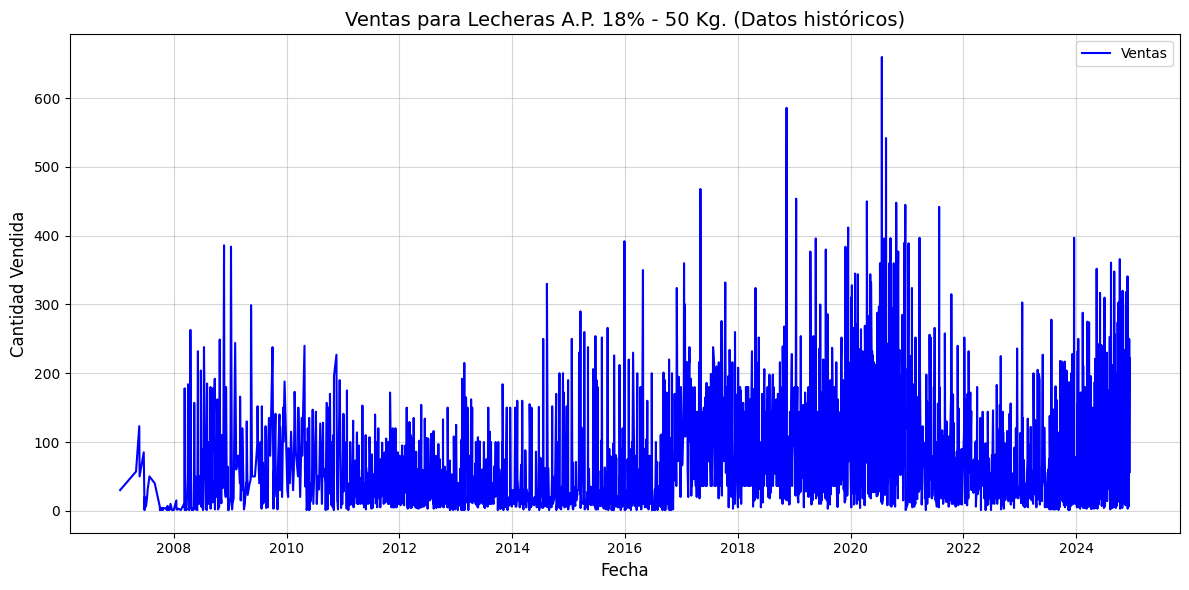

40


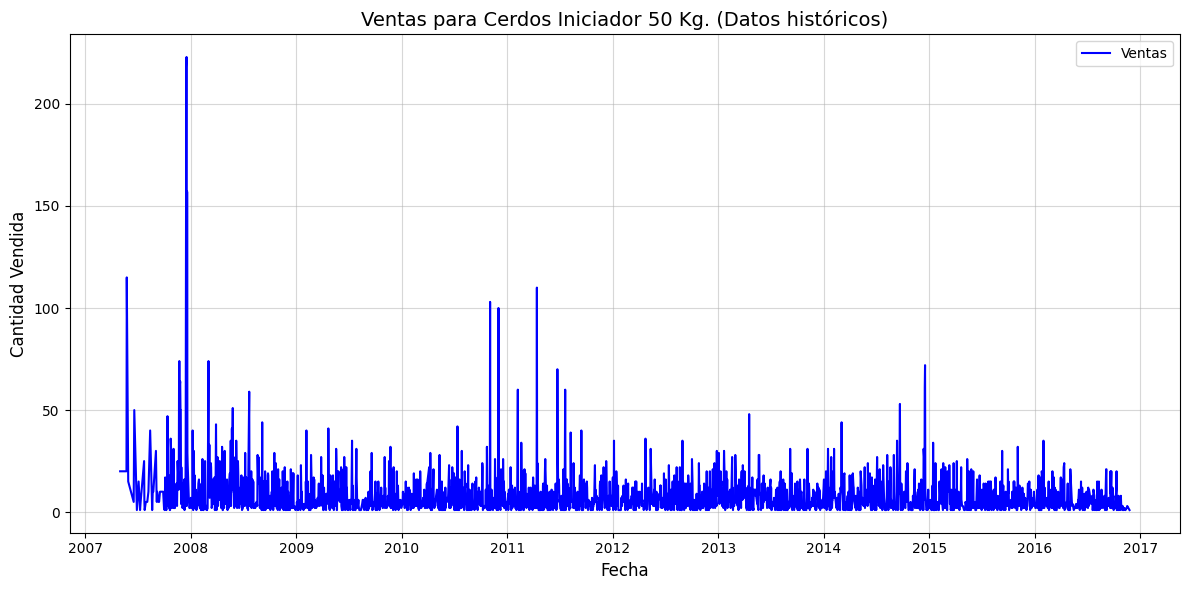

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload the original dataset
file_path = "VENTAS_TROCIUK4.csv"

# Load the dataset (handling encoding and separator issues as before)
df = pd.read_csv(file_path, sep=";", encoding="latin1")

# Ensure column names are standardized for consistent usage
df.columns = [col.strip() for col in df.columns]

# Select relevant columns and ensure proper datetime conversion
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")
df = df[["FECHA", "DESCRIPCION", "TOTAL_CANTIDAD"]].dropna()

# Count occurrences in the "DESCRIPCION" column
descripcion_counts = df["DESCRIPCION"].value_counts()

# Filter "DESCRIPCION" values with more than 3650 records
filtered_descriptions = descripcion_counts[descripcion_counts > 3650].index.tolist()

# Generate plots for each filtered "DESCRIPCION"
i = 0
for description in filtered_descriptions:
    i += 1
    print(i)
    # Filter data for the current "DESCRIPCION"
    df_filtered = df[df["DESCRIPCION"] == description]

    # Aggregate data by date (sum of "TOTAL_CANTIDAD")
    df_grouped = df_filtered.groupby("FECHA")["TOTAL_CANTIDAD"].sum().reset_index()

    # Plot the sales data
    plt.figure(figsize=(12, 6))
    plt.plot(df_grouped["FECHA"], df_grouped["TOTAL_CANTIDAD"], label="Ventas", color="blue")
    plt.title(f"Ventas para {description} (Datos históricos)", fontsize=14)
    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel("Cantidad Vendida", fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
len(filtered_descriptions)

40

In [9]:
df.shape # this data is not the same as the one that i have in the other file, idk what is happening with this file.


(573518, 3)

In [10]:
df

,FECHA,DESCRIPCION,TOTAL_CANTIDAD
0,2003-07-17,Aves Ponedora 50 Kg.,15
1,2003-07-19,Aves Ponedora 50 Kg.,15
2,2003-07-24,Aves Ponedora 50 Kg.,30
3,2003-07-30,Aves Ponedora 50 Kg.,30
4,2003-08-05,Aves Ponedora 50 Kg.,12
...,...,...,...
573513,2024-12-12,Lactomix A.P. HIGH PROTEIN 25 Kg.,6
573514,2024-12-12,Lactomix A.P. HIGH PROTEIN 25 Kg.,45
573515,2024-12-12,Lactomix AP HIGH PROTEIN-Big Bag 1.250 Kg,8
573516,2024-12-12,Pez Crecimiento - 28% (10 mm) - 25 Kg,19
